##**1. Importar as Bibliotecas**

In [3]:
# Manipulação e cálculos
import pandas as pd #Ler, limpar, transformar tabelas
import numpy as np #Cálculos numéricos rápidos (base para Pandas)

# Visualização estática
import matplotlib.pyplot as plt #Criação de gráficos personalizados
import matplotlib.ticker as mtick #formatar, posicionar e controlar os rótulos (ticks) dos eixos X e Y dos gráficos.
import unicodedata  

from pathlib import Path

##**2. Personalizar as configurações de exibição do Pandas:** <br>


In [4]:
pd.set_option('display.max_columns', None) #Exibir todas as colunas do DataFrame
pd.set_option('display.max_rows', None) #Exibir todas as linhas do DataFrame
pd.set_option('display.float_format', lambda x: f'{x:,.2f}') #Formatar números com 2 decimais e separador de milhar

##**3. Carregar os Arquivos CSV**<br>
Dados: [http://vitibrasil.cnpuv.embrapa.br/index.php?opcao=opt_01](http://vitibrasil.cnpuv.embrapa.br/index.php?opcao=opt_01)

In [6]:
import os
print(os.getcwd())

/Users/isabellarodriguessandes/projects/brazil-wine-export-analytics/notebooks


In [7]:
RAW = Path("../data/raw")

# Comercializacao
df_comercializacao = pd.read_csv(RAW / "comercializacao" / "Comercializacao.csv", sep=";")

# Exportacao
df_exportacao_espumantes = pd.read_csv(RAW / "exportacao" / "Exportacao_Espumantes.csv", sep=";")
df_exportacao_suco_uva = pd.read_csv(RAW / "exportacao" / "Exportacao_SucoDeUva.csv", sep=";")
df_exportacao_uvas_frescas = pd.read_csv(RAW / "exportacao" / "Exportacao_UvasFrescas.csv", sep=";")
df_exportacao_vinhos_mesa = pd.read_csv(RAW / "exportacao" / "Exportacao_VinhosDeMesa.csv", sep=";")

# Importacao
df_importacao_espumantes = pd.read_csv(RAW / "importacao" / "Importacao_Espumantes.csv", sep=";")
df_importacao_suco_uva = pd.read_csv(RAW / "importacao" / "Importacao_SucoDeUva.csv", sep=";")
df_importacao_uvas_frescas = pd.read_csv(RAW / "importacao" / "Importacao_UvasFrescas.csv", sep=";")
df_importacao_uvas_passas = pd.read_csv(RAW / "importacao" / "Importacao_UvasPassas.csv", sep=";")
df_importacao_vinhos_mesa = pd.read_csv(RAW / "importacao" / "Importacao_VinhosDeMesa.csv", sep=";")

# Producao
df_producao = pd.read_csv(RAW / "producao" / "Producao.csv", sep=";")

In [8]:
#Validar se tudo foi carregado corretamente
for nome, df in {
    "Comercialização": df_comercializacao,
    "Exportação Espumantes": df_exportacao_espumantes,
    "Exportação Suco": df_exportacao_suco_uva,
    "Exportação Uvas Frescas": df_exportacao_uvas_frescas,
    "Exportação Vinhos": df_exportacao_vinhos_mesa,
    "Importação Espumantes": df_importacao_espumantes,
    "Importação Suco": df_importacao_suco_uva,
    "Importação Uvas Frescas": df_importacao_uvas_frescas,
    "Importação Uvas Passas": df_importacao_uvas_passas,
    "Importação Vinhos": df_importacao_vinhos_mesa,
    "Produção": df_producao
}.items():
    print(nome, "→", df.shape)

Comercialização → (62, 58)
Exportação Espumantes → (103, 110)
Exportação Suco → (122, 110)
Exportação Uvas Frescas → (134, 110)
Exportação Vinhos → (137, 110)
Importação Espumantes → (45, 110)
Importação Suco → (29, 110)
Importação Uvas Frescas → (20, 110)
Importação Uvas Passas → (35, 110)
Importação Vinhos → (68, 110)
Produção → (51, 57)


##**4. Tratamento e Modelagem dos Dados - Importação e Exportação**

###**4.1. Tratamento e normalização das bases**<br>

As bases de importação e exportação são disponibilizadas em formato “largo”, onde:
- cada linha representa um **país**
- os anos aparecem como **colunas**
- para cada ano existem duas informações: **volume e valor (US$)** (ex.: 1970 e 1970.1)<br>

Esse formato não é ideal para análises e visualizações, então foi necessário padronizar as tabelas para um modelo analítico (formato “longo”), com as colunas:<br>
País | ano | volume | valor

Para isso, criei a função **tratar_base_importacao_exportacao(df)**, que aplica os seguintes passos:

1. **Padronização de nomes de colunas**
Renomeia automaticamente colunas do tipo:
  1970 → 1970_volume
  1970.1 → 1970_valor
  garantindo consistência para transformação posterior.

2. **Transformação do formato largo → longo (melt)**
Converte as colunas de ano em linhas, criando uma coluna única que concentra os valores.

3. **Separação do “ano” e do “tipo” (volume/valor)**
Extrai:
  - o ano (4 dígitos)
  - o tipo da métrica (volume ou valor)

4. **Reestruturação final (pivot)**
Volta a organizar os dados, criando duas colunas finais:
  - volume
  - valor

5. **Ajuste de tipos e limpeza**
Converte os campos para tipos numéricos e trata inconsistências.

6. **Recorte temporal para análise (últimos 15 anos)**
Mantém apenas os dados a partir de **2009**, garantindo foco na análise recente e reduzindo ruídos históricos (2009–2023).

In [9]:
def tratar_base_importacao_exportacao(df):
    # =========================
    # ETAPA 1 — Renomear colunas de ano
    colunas_novas = {}

    for col in df.columns:
        if col in ["Id", "País"]:
            colunas_novas[col] = col
        elif ".1" in col:
            ano = col.replace(".1", "")
            colunas_novas[col] = f"{ano}_valor"
        else:
            colunas_novas[col] = f"{col}_volume"

    df = df.rename(columns=colunas_novas)

    # =========================
    # ETAPA 2 — Transformar base (largo → longo)
    id_vars = [c for c in ["Id", "País"] if c in df.columns]

    df_long = df.melt(
        id_vars=id_vars,
        var_name="coluna",
        value_name="valor"
    )

    df_long["ano"] = df_long["coluna"].str.extract(r"(\d{4})")
    df_long["tipo"] = df_long["coluna"].str.extract(r"_(volume|valor)")

    # remove linhas inválidas
    df_long = df_long.dropna(subset=["ano", "tipo"])

    # =========================
    # ETAPA 3 — Pivotar volume e valor
    df_final = (
        df_long
        .pivot_table(
            index=id_vars + ["ano"],
            columns="tipo",
            values="valor",
            aggfunc="first"
        )
        .reset_index()
    )

    df_final.columns.name = None

    # =========================
    # ETAPA 4 — Ajustar tipos de dados
    df_final["ano"] = df_final["ano"].astype(int)
    df_final["volume"] = pd.to_numeric(df_final["volume"], errors="coerce")

    # valor pode vir como string; converte com segurança
    df_final["valor"] = pd.to_numeric(df_final["valor"], errors="coerce")

    # =========================
    # ETAPA 5 — Filtrar últimos 15 anos (>=2009)
    df_final = df_final[df_final["ano"] >= 2009].reset_index(drop=True)

    # =========================
    # ETAPA 6 — Reordenar colunas (se existir Id, mantém)
    colunas_saida = [c for c in ["Id", "País", "ano", "volume", "valor"] if c in df_final.columns]
    df_final = df_final[colunas_saida]

    return df_final

In [10]:
#Importacao
df_importacao_espumantes_modelado = tratar_base_importacao_exportacao(df_importacao_espumantes)
df_importacao_suco_uva_modelado = tratar_base_importacao_exportacao (df_importacao_suco_uva)
df_importacao_uvas_frescas_modelado = tratar_base_importacao_exportacao (df_importacao_uvas_frescas)
df_importacao_uvas_passas_modelado = tratar_base_importacao_exportacao (df_importacao_uvas_passas)
df_importacao_vinhos_mesa_modelado = tratar_base_importacao_exportacao (df_importacao_vinhos_mesa)

#Exportacao
df_exportacao_espumantes_modelado = tratar_base_importacao_exportacao(df_exportacao_espumantes)
df_exportacao_suco_uva_modelado = tratar_base_importacao_exportacao(df_exportacao_suco_uva)
df_exportacao_uvas_frescas_modelado = tratar_base_importacao_exportacao(df_exportacao_uvas_frescas)
df_exportacao_vinhos_mesa_modelado = tratar_base_importacao_exportacao(df_exportacao_vinhos_mesa)

##**5. Tratamento e Modelagem dos Dados - Produção e Comercialização**

###**5.1. Tratamento e normalização das bases**<br>
As bases de Produção e Comercialização são disponibilizadas em formato “largo”, com os anos distribuídos em colunas. Para viabilizar análises temporais, comparações entre categorias e integração com as demais bases do projeto, foi aplicada uma transformação para o formato “longo”, padronizando o modelo para:

(id) | produto | (categoria/linha) | ano | volume

A função **tratar_base_producao_comercializacao()** executa:
- padronização dos nomes das colunas;
- identificação automática das colunas de ano;
- transformação largo → longo (melt);
- conversão de tipos numéricos;
- classificação da linha (quando existe categoria);
- recorte temporal para o período de análise dos últimos 15 anos (2009–2023).

In [11]:
def tratar_base_producao_comercializacao(df):
    df = df.copy()

    # =========================
    # ETAPA 1 — Padronizar nomes das colunas
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
    )

    # =========================
    # ETAPA 2 — Renomear colunas fixas (quando existirem)
    df = df.rename(columns={
        "produto": "produto",
        "control": "categoria"
    })

    # =========================
    # ETAPA 3 — Definir colunas de identificação dinamicamente
    id_vars = [c for c in ["id", "produto", "categoria"] if c in df.columns]

    # =========================
    # ETAPA 4 — Identificar colunas de ANO (somente números)
    col_anos = [col for col in df.columns if col.isdigit()]

    # =========================
    # ETAPA 5 — Transformar base (largo → longo)
    df_long = df.melt(
        id_vars=id_vars,
        value_vars=col_anos,
        var_name="ano",
        value_name="volume"
    )

    # =========================
    # ETAPA 6 — Ajustar tipos de dados
    df_long["ano"] = df_long["ano"].astype(int)
    df_long["volume"] = pd.to_numeric(df_long["volume"], errors="coerce")

    # =========================
    # ETAPA 7 — Classificação (se existir categoria)
    if "categoria" in df_long.columns:
        df_long["codigo_linha"] = df_long["categoria"].str.extract(r"^([a-z]{2})")

        mapa_linha = {
            "vm": "Vinho de Mesa",
            "ve": "Vinho Especial",
            "es": "Espumantes",
            "su": "Sucos",
            "ou": "Outros"
        }

        df_long["linha"] = df_long["codigo_linha"].map(mapa_linha)

    # =========================
    # ETAPA 8 — Filtrar período de análise (2009–2023)
    df_final = (
        df_long[(df_long["ano"] >= 2009) & (df_long["ano"] <= 2023)]
        .reset_index(drop=True)
    )

    # =========================
    # ETAPA 9 — Reordenar as colunas (mantém linha se existir)
    colunas_saida = [c for c in ["id", "ano", "produto", "volume", "linha"] if c in df_final.columns]
    df_final = df_final[colunas_saida]

    return df_final

In [12]:
#Producao
df_producao_tratado = tratar_base_producao_comercializacao(df_producao)

#Comercializacao
df_comercializacao_tratado = tratar_base_producao_comercializacao(df_comercializacao)

###**5.2. Modelagem de Produto (hierarquia analítica)**<br>
As bases de Produção e Comercialização possuem o campo **produto** com descrições em diferentes níveis de detalhe (ex.: “Vinho de mesa”, “Tinto”, “Espumante moscatel”, “Mosto concentrado”, etc.).
Esse cenário dificulta análises executivas, porque o mesmo universo pode aparecer misturado entre:
- **itens agregados** (ex.: “Vinho de mesa”, “Suco”, “Derivados”)
- **itens detalhados** (ex.: “Tinto”, “Branco”, “Espumante”, “Borra líquida”)

Para garantir consistência e permitir análises em múltiplos níveis, foi criada uma hierarquia de produtos, classificando cada item em:
- **categoria_produto** (ex.: Vinho, Suco, Espumante, Mosto, Destilado, Derivados)
- **subcategoria_produto** (ex.: Vinho de Mesa, Vinífera, Base, Produto Final, Intermediário)
- **nivel_produto** (nível analítico: 1 = agregado | 2 = intermediário | 3 = detalhado)
- **agregado** (flag booleana indicando se é uma linha “resumo oficial”)

A função **classificar_produto()** aplica regras por palavras-chave e mapeamentos oficiais para transformar o campo produto em uma estrutura padronizada e comparável.
Em seguida, **aplicar_modelagem_produto()** enriquece os DataFrames de produção e comercialização, adicionando as colunas hierárquicas, mantendo a base pronta para agregações, comparações e construção de indicadores no Power BI.


In [13]:
def _normalizar_texto(s: str) -> str:
    s = str(s).lower().strip()
    s = " ".join(s.split())  # remove espaços duplicados
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("utf-8")  # remove acentos
    return s

def mapear_hierarquia_produto(produto):
    p = _normalizar_texto(produto)

    # =========================
    # Bebidas mistas (captura Cooler / Sangria / Coquetel...)
    if "cooler" in p or "sangria" in p or "coquetel" in p:
        return ("Outros", "Bebidas Mistas", 3, False)

    # =========================
    # Guarda-chuva "Outros produtos"
    # (captura: "OUTROS PRODUTOS COMERCIALIZADOS" e "Outros produtos")
    if p == "outros produtos" or "outros produtos comercializados" in p:
        return ("Outros", "Outros Produtos", 1, True)

    # =========================
    # Vinagre / acetificados
    if "vinagre" in p or "acetific" in p:
        return ("Derivados", "Vinagre", 3, False)

    # =========================
    # Agregados (nível 1)
    agregados = {
        "vinho de mesa": ("Vinho", "Vinho de Mesa", 1, True),
        "vinho fino de mesa": ("Vinho", "Vinifera", 1, True),
        "vinho fino de mesa (vinifera)": ("Vinho", "Vinifera", 1, True),
        "vinho especial": ("Vinho", "Especial", 1, True),
        "suco": ("Suco", "Suco de Uva", 1, True),
        "suco de uvas": ("Suco", "Suco de Uva", 1, True),
        "derivados": ("Derivados", "Derivados Industriais", 1, True),
    }
    if p in agregados:
        return agregados[p]

    # =========================
    # Vinhos
    if p in ["tinto", "branco", "rosado"]:
        return ("Vinho", "Vinho de Mesa", 3, False)

    if "licoroso" in p:
        return ("Vinho", "Produto Final", 3, False)

    if (
        "vinho leve" in p or
        "vinho composto" in p or
        "vinho gaseificado" in p or
        "outros vinhos" in p
    ):
        return ("Vinho", "Produto Final", 3, False)

    if "vinho org" in p:
        return ("Vinho", "Organico", 3, False)

    if "vinho" in p:
        return ("Vinho", "Produto Final", 3, False)

    # =========================
    # Espumantes
    if "vinho base para espum" in p or "base" in p:
        return ("Espumante", "Base", 2, False)

    if "espumante" in p or "frisante" in p or "frizante" in p:
        return ("Espumante", "Produto Final", 3, False)

    # =========================
    # Sucos
    if (
        "suco" in p or "nectar" in p or
        "polpa" in p or "bebida de uva" in p or
        "refresco" in p or "refrigerante" in p
    ):
        return ("Suco", "Suco de Uva", 3, False)

    # =========================
    # Mostos
    if "mosto" in p or p in ["mistelas", "jeropiga"]:
        return ("Mosto", "Intermediario", 2, False)

    # =========================
    # Destilados
    if (
        "destilado" in p or "bagaceira" in p or "brandy" in p or
        "pisco" in p or "aguardente" in p or "alcool vinico" in p
    ):
        return ("Destilado", "Produto Final", 3, False)

    # =========================
    # Derivados industriais
    if (
        "composto" in p or "filtrado" in p or
        "borra" in p or "derivado" in p or "agrin" in p
    ):
        return ("Derivados", "Derivados Industriais", 2, False)

    return ("Outros", "Outros", 3, False)

In [14]:
def aplicar_modelagem_produto(df, coluna_produto="produto"):
    """
    Aplica a hierarquia analítica de produto em um DataFrame.
    Utiliza a função mapear_hierarquia_produto para cada linha.
    """

    df = df.copy()

    if coluna_produto not in df.columns:
        raise ValueError(f"Coluna '{coluna_produto}' não encontrada no DataFrame")

    classificacao = df[coluna_produto].apply(mapear_hierarquia_produto)

    df["categoria_produto"] = classificacao.apply(lambda x: x[0])
    df["subcategoria_produto"] = classificacao.apply(lambda x: x[1])
    df["nivel_produto"] = classificacao.apply(lambda x: x[2])
    df["eh_agregado"] = classificacao.apply(lambda x: x[3])

    return df

In [15]:
#Producao
df_producao_modelado = aplicar_modelagem_produto(df_producao_tratado)

#Comercializacao
df_comercializacao_modelado = aplicar_modelagem_produto(df_comercializacao_tratado)

**Salvar os dados tratados em data/processed/**

In [16]:
PROCESSED = Path("../data/processed")
PROCESSED.mkdir(parents=True, exist_ok=True)

# Importacao (modelados)
df_importacao_espumantes_modelado.to_csv(PROCESSED / "importacao_espumantes_modelado.csv", index=False)
df_importacao_suco_uva_modelado.to_csv(PROCESSED / "importacao_suco_uva_modelado.csv", index=False)
df_importacao_uvas_frescas_modelado.to_csv(PROCESSED / "importacao_uvas_frescas_modelado.csv", index=False)
df_importacao_uvas_passas_modelado.to_csv(PROCESSED / "importacao_uvas_passas_modelado.csv", index=False)
df_importacao_vinhos_mesa_modelado.to_csv(PROCESSED / "importacao_vinhos_mesa_modelado.csv", index=False)

# Exportacao (modelados)
df_exportacao_espumantes_modelado.to_csv(PROCESSED / "exportacao_espumantes_modelado.csv", index=False)
df_exportacao_suco_uva_modelado.to_csv(PROCESSED / "exportacao_suco_uva_modelado.csv", index=False)
df_exportacao_uvas_frescas_modelado.to_csv(PROCESSED / "exportacao_uvas_frescas_modelado.csv", index=False)
df_exportacao_vinhos_mesa_modelado.to_csv(PROCESSED / "exportacao_vinhos_mesa_modelado.csv", index=False)

# Producao / Comercializacao (modelados)
df_producao_modelado.to_csv(PROCESSED / "producao_modelado.csv", index=False)
df_comercializacao_modelado.to_csv(PROCESSED / "comercializacao_modelado.csv", index=False)

##**6. Tabela Fato — Comércio Exterior de Vinhos**<br>
Nesta etapa foi construída a **Tabela Fato de Comércio Exterior**, que consolida todas as **operações de Importação e Exportação** em um único modelo analítico, padronizado e pronto para análises em BI.<br>
Modelo:
- **Tipo** → Importação ou Exportação
- **Categoria** → Espumantes, Vinhos de Mesa, Suco de Uva, etc.
- **País de origem / destino** → Parceiros comerciais
- **Ano** → Dimensão temporal
- **Volume (L)** → Quantidade comercializada (1 KG = 1 L)
- **Valor (US$)** → Valor financeiro da operação

In [17]:
def criar_tabelafato_comercio(df, tipo, categoria):

    df = df.copy()

    # =========================
    # Validação defensiva (colunas esperadas)
    colunas_esperadas = {"ano", "País", "volume", "valor"}
    faltando = colunas_esperadas - set(df.columns)
    if faltando:
        raise ValueError(
            f"Colunas faltando no DataFrame: {faltando}. "
            f"Esperado: {sorted(colunas_esperadas)}"
        )

    # =========================
    # Padronização de tipos (conversão segura)
    df["ano"] = pd.to_numeric(df["ano"], errors="coerce").astype("Int64")
    df["volume"] = pd.to_numeric(df["volume"], errors="coerce")
    df["valor"] = pd.to_numeric(df["valor"], errors="coerce")

    # =========================
    # Regras de origem/destino por tipo de operação
    if tipo == "Importação":
        pais_origem = df["País"]
        pais_destino = "Brasil"
    elif tipo == "Exportação":
        pais_origem = "Brasil"
        pais_destino = df["País"]
    else:
        raise ValueError("tipo deve ser 'Importação' ou 'Exportação'.")

    # =========================
    # Montagem da tabela fato (1 KG = 1 L)
    df_fato = (
        df.assign(
            **{
                "Tipo": tipo,
                "Categoria": categoria,
                "País de origem": pais_origem,
                "País de destino": pais_destino,
                "Ano": df["ano"],
                "Volume (L)": df["volume"],
                "Valor (US$)": df["valor"],
            }
        )
        .loc[:, [
            "Tipo", "Categoria",
            "País de origem", "País de destino",
            "Ano", "Volume (L)", "Valor (US$)"
        ]]
    )

    return df_fato

In [18]:
#Importação
df_importacao_espumantes_tabelafato   = criar_tabelafato_comercio(df_importacao_espumantes_modelado,   "Importação", "Espumantes")
df_importacao_suco_uva_tabelafato     = criar_tabelafato_comercio(df_importacao_suco_uva_modelado,     "Importação", "Suco de uva")
df_importacao_uvas_frescas_tabelafato = criar_tabelafato_comercio(df_importacao_uvas_frescas_modelado, "Importação", "Uvas frescas")
df_importacao_uvas_passas_tabelafato  = criar_tabelafato_comercio(df_importacao_uvas_passas_modelado,  "Importação", "Uvas passas")
df_importacao_vinhos_mesa_tabelafato  = criar_tabelafato_comercio(df_importacao_vinhos_mesa_modelado,  "Importação", "Vinhos de mesa")

#Exportação
df_exportacao_espumantes_tabelafato   = criar_tabelafato_comercio(df_exportacao_espumantes_modelado,   "Exportação", "Espumantes")
df_exportacao_suco_uva_tabelafato     = criar_tabelafato_comercio(df_exportacao_suco_uva_modelado,     "Exportação", "Suco de uva")
df_exportacao_uvas_frescas_tabelafato = criar_tabelafato_comercio(df_exportacao_uvas_frescas_modelado, "Exportação", "Uvas frescas")
df_exportacao_vinhos_mesa_tabelafato  = criar_tabelafato_comercio(df_exportacao_vinhos_mesa_modelado,  "Exportação", "Vinhos de mesa")


#União final (tabela fato consolidada para análises gerais)
lista_fatos = [
    df_importacao_espumantes_tabelafato,
    df_importacao_suco_uva_tabelafato,
    df_importacao_uvas_frescas_tabelafato,
    df_importacao_uvas_passas_tabelafato,
    df_importacao_vinhos_mesa_tabelafato,
    df_exportacao_espumantes_tabelafato,
    df_exportacao_suco_uva_tabelafato,
    df_exportacao_uvas_frescas_tabelafato,
    df_exportacao_vinhos_mesa_tabelafato
]

fato_comercio = pd.concat(lista_fatos, ignore_index=True)

#Garantir tipos após concat
fato_comercio["Ano"] = pd.to_numeric(fato_comercio["Ano"], errors="coerce").astype("Int64")
fato_comercio["Volume (L)"] = pd.to_numeric(fato_comercio["Volume (L)"], errors="coerce")
fato_comercio["Valor (US$)"] = pd.to_numeric(fato_comercio["Valor (US$)"], errors="coerce")

# Chave técnica de registro (rastreabilidade / duplicidade): Essa chave tem como objetivo facilitar auditorias,
#detecção de duplicidades e rastreabilidade dos dados ao longo das análises.
fato_comercio["chave_registro"] = (
    fato_comercio["Tipo"].astype(str) + "|" +
    fato_comercio["Categoria"].astype(str) + "|" +
    fato_comercio["País de origem"].astype(str) + "|" +
    fato_comercio["País de destino"].astype(str) + "|" +
    fato_comercio["Ano"].astype(str)
)

In [19]:
top3_fato_vinhos_mesa = (
    fato_comercio
        .query("Tipo == 'Exportação' and Categoria == 'Vinhos de mesa'")
        .groupby("País de destino", as_index=False)["Volume (L)"]
        .sum()
        .assign(**{"Volume (t)": lambda d: d["Volume (L)"] / 1_000})
        .sort_values("Volume (t)", ascending=False)
        .head(3)
        .reset_index(drop=True)
)

top3_fato_vinhos_mesa

,País de destino,Volume (L),Volume (t)
0,Rússia,"32,822,141.00","32,822.14"
1,Paraguai,"30,803,247.00","30,803.25"
2,Estados Unidos,"3,349,299.00","3,349.30"


##**7. Análise Exploratória de Dados (EDA)**<br>
###**Contexto da Análise:**
Nesta etapa, assume-se o papel de Analista de Dados responsável por apoiar decisões estratégicas em uma empresa que atua na exportação de vinhos brasileiros para o mercado internacional.

O objetivo desta Análise Exploratória de Dados (EDA) é fornecer uma visão clara, confiável e orientada a negócio sobre o desempenho das exportações de vinho do Brasil ao longo dos últimos 15 anos, subsidiando uma reunião com investidores e acionistas.

A análise busca responder perguntas-chave como:
- Qual foi o **montante financeiro** gerado pelas exportações de vinhos?
- Quais países se destacam como **principais destinos**?
- Como o volume e o valor exportado evoluíram ao longo do tempo?
- Quais **fatores externos** podem influenciar ou explicar variações observadas nos dados?

###**7.1. Visão Geral das Exportações**<br>
Quanto o Brasil vendeu em exportações de vinho ao longo do tempo?

Mostrar:
- Evolução do **volume total exportado** (litros)
- Evolução do **valor total exportado** (US$)
- Ao longo dos **últimos 15 anos**

Esse gráfico:
- cria contexto
- prepara o terreno para o Top Países
- dá base para falar de fatores externos depois

In [20]:
#Filtrar Exportação e Vinhos de mesa
exportacoes_vinho = fato_comercio[
    (fato_comercio["Tipo"] == "Exportação") &
    (fato_comercio["Categoria"] == "Vinhos de mesa")
].copy()

exportacoes_ano = (
    exportacoes_vinho
    .groupby("Ano", as_index=False)
    .agg({
        "Volume (L)": "sum",
        "Valor (US$)": "sum"
    })
    .sort_values("Ano")
)

exportacoes_ano

,Ano,Volume (L),Valor (US$)
0,2009,"25,514,198.00","8,940,988.00"
1,2010,"1,280,574.00","2,595,303.00"
2,2011,"1,214,834.00","3,615,120.00"
3,2012,"5,775,376.00","5,521,293.00"
4,2013,"9,149,059.00","22,744,845.00"
5,2014,"2,324,029.00","7,472,795.00"
6,2015,"1,198,479.00","2,769,160.00"
7,2016,"1,786,549.00","4,434,704.00"
8,2017,"2,889,572.00","7,135,607.00"
9,2018,"3,856,162.00","7,486,063.00"


**Gráfico Executivo — Evolução das Exportações**<br>
Decisão visual (importante):
- Linha → tendência no tempo
- Dois eixos Y → volume ≠ dinheiro
- Sem poluição visual
- Leitura rápida

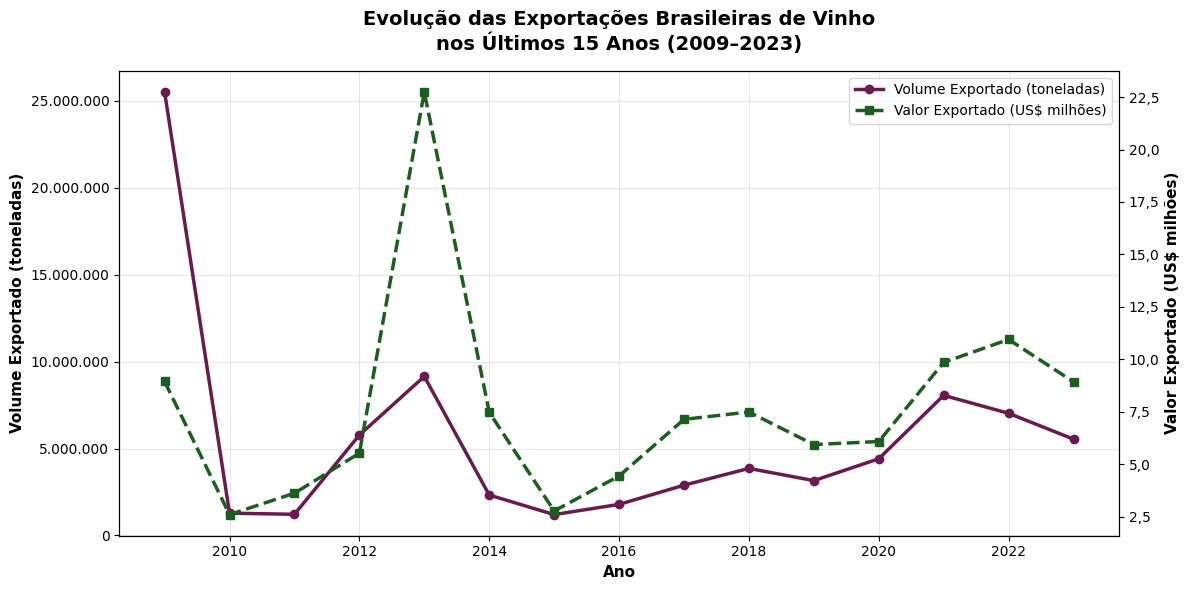

In [21]:
plt.figure(figsize=(12, 6))

# =========================
# Volume exportado (toneladas)
plt.plot(
    exportacoes_ano["Ano"],
    exportacoes_ano["Volume (L)"],  # mantendo exatamente como estava
    marker="o",
    linewidth=2.5,
    color="#6A1B4D",  # vinho escuro
    label="Volume Exportado (toneladas)"
)

ax = plt.gca()
ax.set_xlabel("Ano", fontsize=11, fontweight="bold")
ax.set_ylabel("Volume Exportado (toneladas)", fontsize=11, fontweight="bold")

# Separador de milhar no volume
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", "."))
)

ax.grid(alpha=0.3)

# =========================
# Valor exportado (US$ milhões)
ax2 = ax.twinx()

ax2.plot(
    exportacoes_ano["Ano"],
    exportacoes_ano["Valor (US$)"] / 1_000_000,  # 🔹 alteração: US$ → US$ milhões
    marker="s",
    linestyle="--",
    linewidth=2.5,
    color="#1B5E20",  # verde financeiro
    label="Valor Exportado (US$ milhões)"
)

ax2.set_ylabel("Valor Exportado (US$ milhões)", fontsize=11, fontweight="bold")

# Separador de milhar no valor
ax2.yaxis.set_major_formatter(
    mtick.FuncFormatter(
        lambda x, _: f"{x:,.1f}".replace(",", "X").replace(".", ",").replace("X", ".")
    )
)

# =========================
# Título
ax.set_title(
    "Evolução das Exportações Brasileiras de Vinho\n"
    "nos Últimos 15 Anos (2009–2023)",
    fontsize=14,
    fontweight="bold",
    pad=15
)

# Legenda
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc="upper right")


plt.tight_layout()
plt.show()

O gráfico evidencia elevada volatilidade nas exportações brasileiras de vinho ao longo dos últimos 15 anos, com períodos de forte expansão seguidos por retrações. Destaca-se o pico observado em 2013, especialmente no valor exportado, sugerindo influência de fatores externos como câmbio, composição do mix exportado e concentração em mercados específicos. A partir de 2016, observa-se uma retomada mais consistente, indicando maior estabilidade e potencial de crescimento sustentável.

**1. Alta volatilidade no período**<br>
- As exportações não seguem uma trajetória linear
- Há ciclos claros de expansão e retração<br>
Indício de sensibilidade a fatores externos (câmbio, economia global, acordos comerciais).<br>

---

**2. Pico anormal em 2013 (valor)**<br>
Em 2013:
- Volume cresce
- Valor explode em relação aos outros anos

Forte sinal de:
- câmbio favorável
- exportação de vinhos com maior valor agregado
- ou concentração em poucos mercados dispostos a pagar mais<br>
Esse ponto é excelente para discussão estratégica, não precisa “explicar tudo” agora — só levantar a hipótese.

---

**3. Recuperação consistente pós-2016**<br>
A partir de 2016:
- Volume cresce gradualmente
- Valor acompanha (com pequenas oscilações)
Indício de:
- amadurecimento dos mercados
- retomada após crises econômicas
- maior previsibilidade

---

**4. Volume e valor não crescem sempre juntos**<br>
Exemplos:
- 2018 → 2019:
- Volume cai levemente
- Valor mantém-se

Isso sugere:
- mudança de mix de produtos
- mudança de países compradores
- efeito direto do preço médio do litro<br>
Excelente gancho para análises por país.
---

###**7.2. Top 3 Países de Destino das Exportações de Vinho (por Volume)**<br>
Para quem o Brasil está vendendo vinho?
- mostra concentração de mercado
- identifica dependência de poucos países
- revela prioridades estratégicas

---

- Quem são os principais compradores
- Se o volume está pulverizado ou concentrado
- Onde focar:
  - marketing
  - acordos comerciais
  - expansão

Após analisar a evolução temporal das exportações brasileiras de vinho, o próximo passo é identificar os principais países de destino, avaliando onde se concentra o volume exportado ao longo do período analisado.

In [22]:
top5_paises_exportacoes_vinho = (
    exportacoes_vinho
    .groupby("País de destino", as_index=False)["Volume (L)"]
    .sum()
    .sort_values("Volume (L)", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

top5_paises_exportacoes_vinho["Volume (MM L)"] = top5_paises_exportacoes_vinho["Volume (L)"] / 1_000_000

top5_paises_exportacoes_vinho

,País de destino,Volume (L),Volume (MM L)
0,Rússia,"32,822,141.00",32.82
1,Paraguai,"30,803,247.00",30.80
2,Estados Unidos,"3,349,299.00",3.35
3,China,"2,574,686.00",2.57
4,Haiti,"2,351,228.00",2.35


In [23]:
top3_paises_exportacoes_vinho = (
    exportacoes_vinho
        .groupby("País de destino", as_index=False)["Volume (L)"]
        .sum()
        .sort_values("Volume (L)", ascending=False)
        .head(3)
        .reset_index(drop=True)
)

# 🔹 Converter para toneladas
top3_paises_exportacoes_vinho["Volume (toneladas)"] = (
    top3_paises_exportacoes_vinho["Volume (L)"] / 1_000
)

top3_paises_exportacoes_vinho

,País de destino,Volume (L),Volume (toneladas)
0,Rússia,"32,822,141.00","32,822.14"
1,Paraguai,"30,803,247.00","30,803.25"
2,Estados Unidos,"3,349,299.00","3,349.30"


<Figure size 1200x600 with 0 Axes>

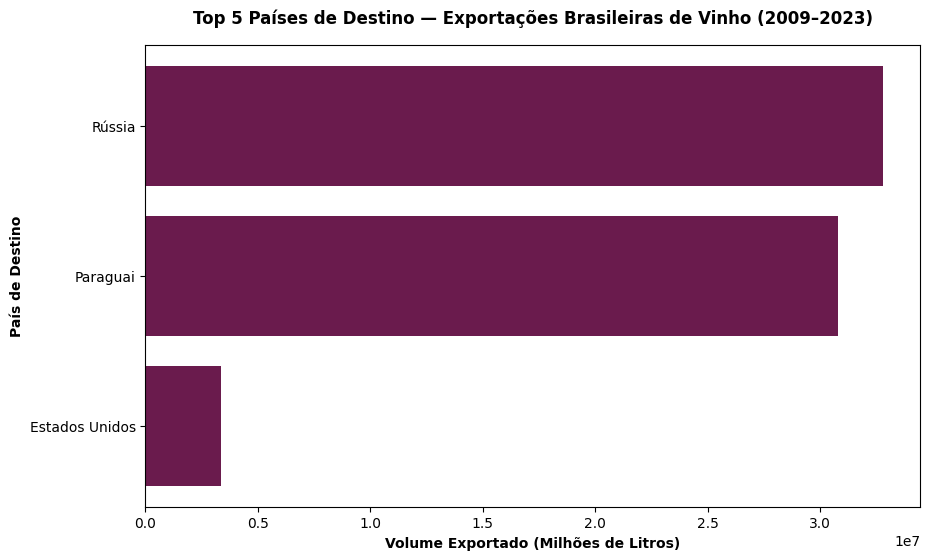

In [24]:
plt.figure(figsize=(12, 6))

# Dados
paises = top3_paises_exportacoes_vinho["País de destino"]
volumes = top3_paises_exportacoes_vinho["Volume (L)"]

# Definição das cores
cores = [
    '#5A0F2E' if pais in ['Rússia', 'Paraguai'] else '#9E9E9E'
    for pais in paises
]

# Gráfico
plt.figure(figsize=(10, 6))

plt.barh(
    paises,
    volumes,
    color="#6A1B4D"
)

plt.gca().invert_yaxis()

plt.xlabel("Volume Exportado (Milhões de Litros)", fontweight="bold")
plt.ylabel("País de Destino", fontweight="bold")
plt.title(
    "Top 5 Países de Destino — Exportações Brasileiras de Vinho (2009–2023)",
    pad=15,
    fontweight="bold"
)

plt.show()

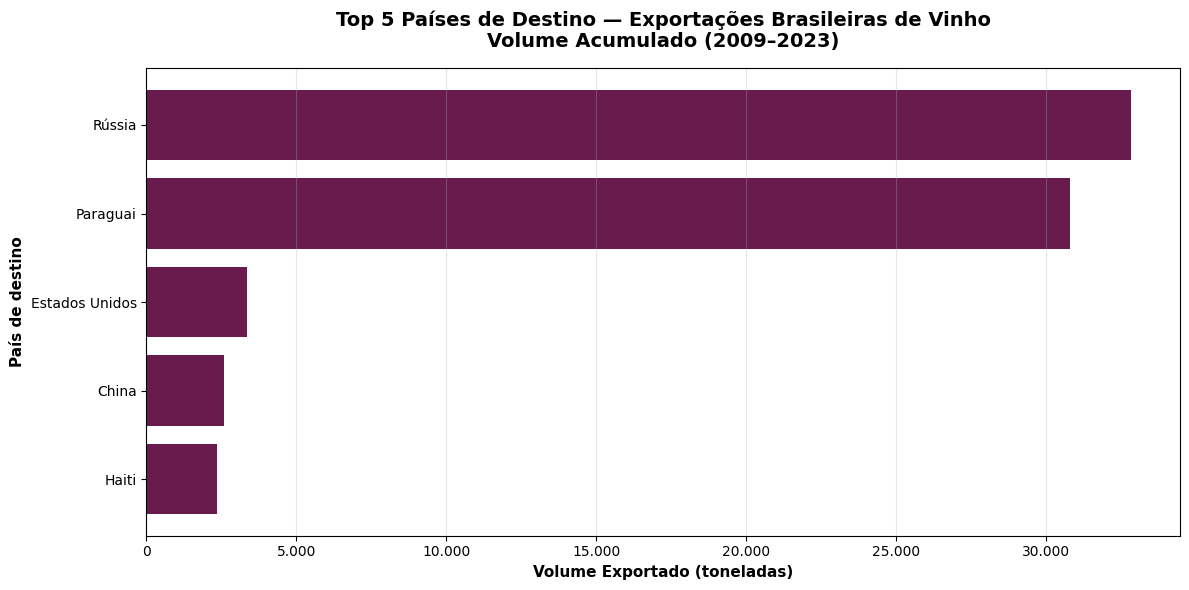

In [ ]:
plt.figure(figsize=(12, 6))

# =========================
# Dados
paises = top5_paises_exportacoes_vinho["País de destino"]

# Volume em toneladas
# Volume (MM L) = milhões de litros
# 1.000 L = 1 tonelada → milhões de litros = milhares de toneladas
volumes_toneladas = top5_paises_exportacoes_vinho["Volume (MM L)"] * 1_000

# =========================
# Gráfico de barras horizontais
plt.barh(
    paises,
    volumes_toneladas,
    color="#6A1B4D"
)

plt.gca().invert_yaxis()

ax = plt.gca()

# =========================
# Rótulos
ax.set_xlabel("Volume Exportado (toneladas)", fontsize=11, fontweight="bold")
ax.set_ylabel("País de destino", fontsize=11, fontweight="bold")

# Formatação do eixo X (milhar com ponto)
ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", "."))
)

# Grid (mesmo padrão do outro gráfico)
ax.grid(axis="x", alpha=0.3)

# =========================
# Título
ax.set_title(
    "Top 5 Países de Destino — Exportações Brasileiras de Vinho\n"
    "Volume Acumulado (2009–2023)",
    fontsize=14,
    fontweight="bold",
    pad=15
)

# =========================
# Layout final
plt.tight_layout()
plt.show()

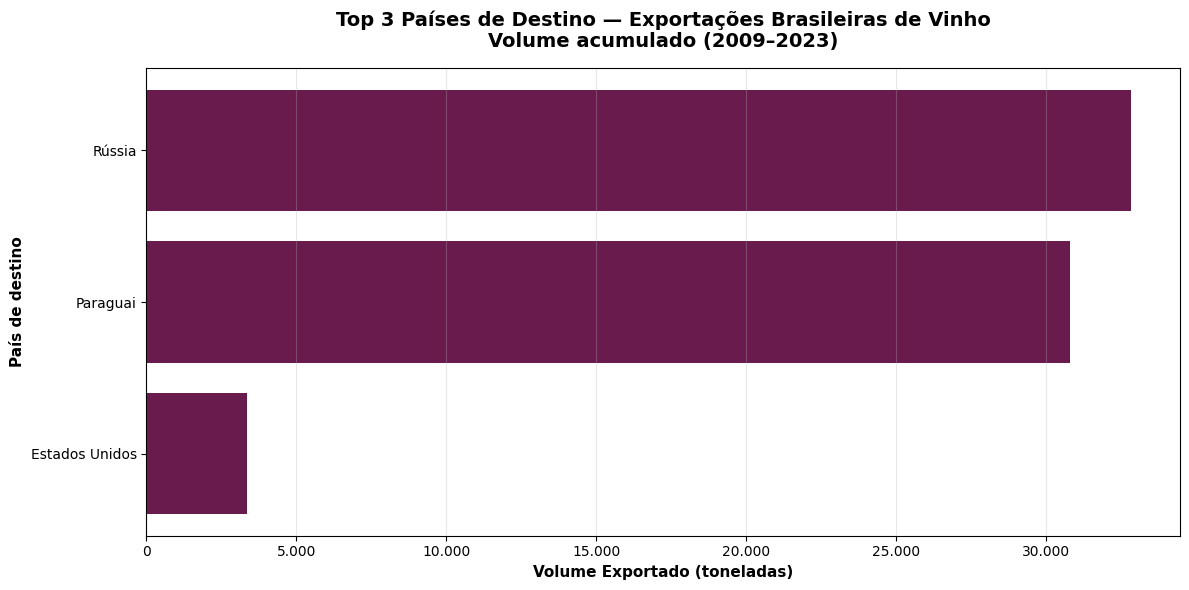

In [25]:
plt.figure(figsize=(12, 6))

# =========================
# Dados
paises = top3_paises_exportacoes_vinho["País de destino"]
volumes = top3_paises_exportacoes_vinho["Volume (toneladas)"]

# =========================
# Gráfico de barras horizontais
plt.barh(
    paises,
    volumes,
    color="#6A1B4D"
)

plt.gca().invert_yaxis()
ax = plt.gca()

# =========================
# Rótulos
ax.set_xlabel("Volume Exportado (toneladas)", fontsize=11, fontweight="bold")
ax.set_ylabel("País de destino", fontsize=11, fontweight="bold")

# Formatação PT-BR (milhar com ponto)
ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", "."))
)

ax.grid(axis="x", alpha=0.3)

# =========================
# Título (ajustado para Top 3)
ax.set_title(
    "Top 3 Países de Destino — Exportações Brasileiras de Vinho\n"
    "Volume acumulado (2009–2023)",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

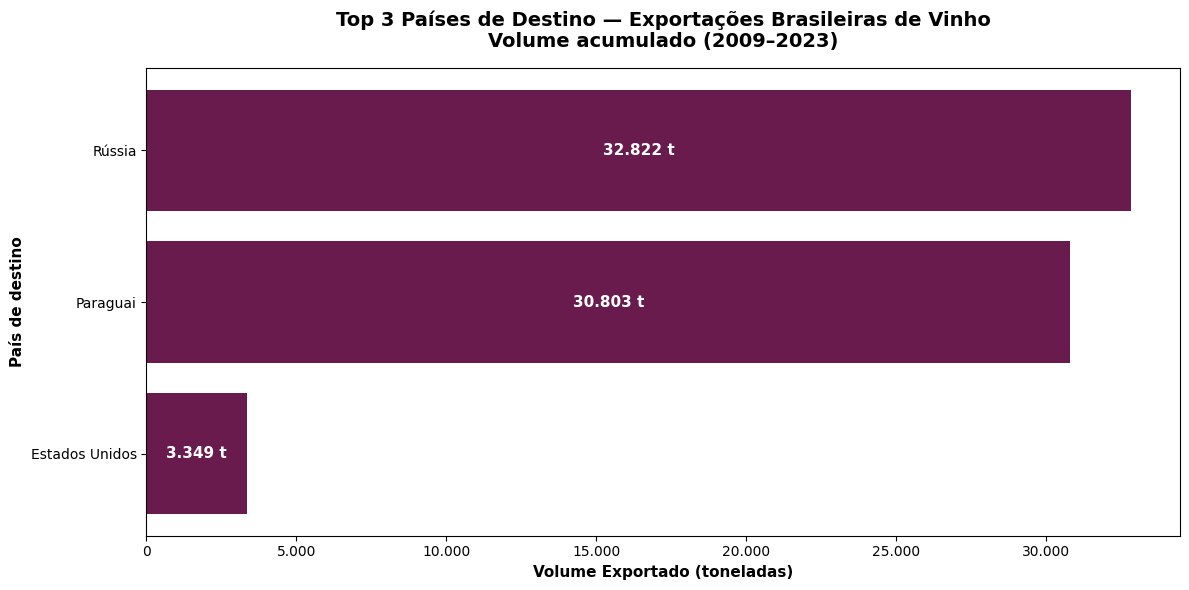

In [ ]:
plt.figure(figsize=(12, 6))

# =========================
# Dados
paises = top3_paises_exportacoes_vinho["País de destino"]
volumes = top3_paises_exportacoes_vinho["Volume (toneladas)"]

# =========================
# Gráfico de barras horizontais
plt.barh(
    paises,
    volumes,
    color="#6A1B4D"
)

plt.gca().invert_yaxis()
ax = plt.gca()

# =========================
# Rótulos dos eixos
ax.set_xlabel("Volume Exportado (toneladas)", fontsize=11, fontweight="bold")
ax.set_ylabel("País de destino", fontsize=11, fontweight="bold")

# Formatação PT-BR
ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", "."))
)

# =========================
# Título
ax.set_title(
    "Top 3 Países de Destino — Exportações Brasileiras de Vinho\n"
    "Volume acumulado (2009–2023)",
    fontsize=14,
    fontweight="bold",
    pad=15
)

# =========================
# 🔹 Rótulos NO MEIO da barra
for i, v in enumerate(volumes):
    ax.text(
        v / 2,                               # meio da barra
        i,
        f"{int(v):,}".replace(",", ".") + " t",
        va="center",
        ha="center",
        fontsize=11,
        fontweight="bold",
        color="white"
    )

plt.tight_layout()
plt.show()

Entre 2009 e 2023, as exportações brasileiras de vinhos de mesa se concentraram fortemente em poucos mercados. Rússia e Paraguai lideram com ampla vantagem em volume, enquanto Estados Unidos, China e Haiti aparecem como mercados secundários, com volumes significativamente menores.<br>
- **Alta concentração**: Top 2 representam a maior parte do volume exportado
- **Dependência geográfica**: risco estratégico se houver barreiras comerciais
- **Potencial de diversificação**: EUA e China têm baixo volume relativo, mas alto potencial de valor agregado

###**7.3. Evolução temporal dos Top 3 países de destino**<br>
Esses países cresceram de forma consistente ou dependem de picos pontuais?<br>
Analisar como evoluiu o volume de exportação de vinhos brasileiros ao longo do tempo para os 3 principais países de destino, permitindo:
- Identificar **crescimento, retração ou volatilidade**
- Comparar **trajetórias entre mercados**
- Criar base para **discussão de fatores externos** (economia, câmbio, conflitos, clima, consumo)

In [26]:
top3_paises_exportacoes_vinho = (
    exportacoes_vinho
    .groupby("País de destino", as_index=False)["Volume (L)"]
    .sum()
    .sort_values("Volume (L)", ascending=False)
    .head(3)["País de destino"]
    .tolist()
)

top3_paises_exportacoes_vinho

['Rússia', 'Paraguai', 'Estados Unidos']

In [27]:
evolucao_top3_paises_exportacoes_vinho = (
    exportacoes_vinho[
        exportacoes_vinho["País de destino"].isin(top3_paises_exportacoes_vinho)
    ]
    .groupby(["Ano", "País de destino"], as_index=False)
    .agg({
        "Volume (L)": "sum"
    })
)

evolucao_top3_paises_exportacoes_vinho["Volume (MM L)"] = evolucao_top3_paises_exportacoes_vinho["Volume (L)"] / 1_000_000


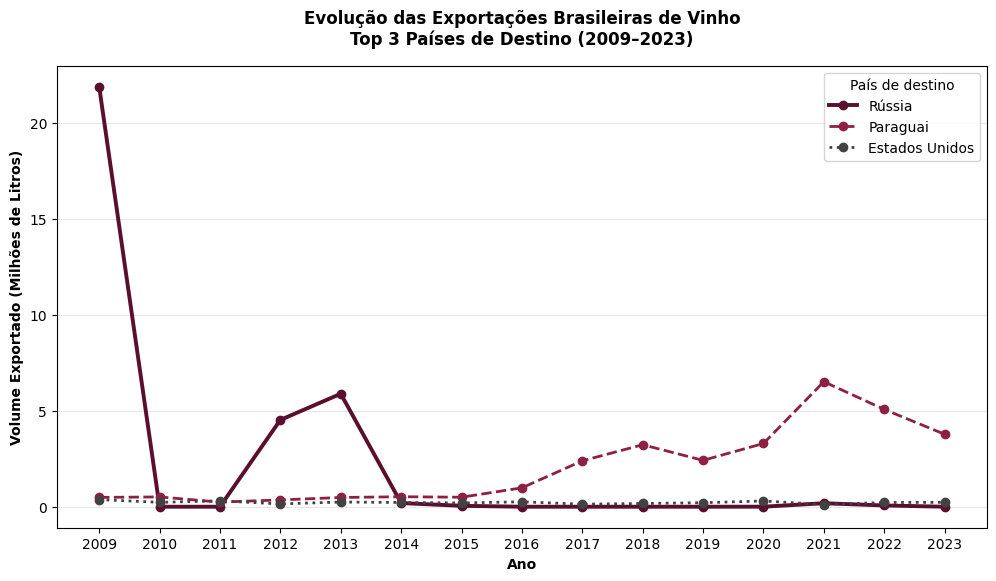

In [28]:
cores_paises = {
    "Rússia": "#5A0F2E",        # vinho escuro (destaque)
    "Paraguai": "#8E2043",     # vinho médio (segundo plano)
    "Estados Unidos": "#424242"  # cinza escuro (comparativo)
}

estilos_linha = {
    "Rússia": "-",
    "Paraguai": "--",
    "Estados Unidos": ":"
}

plt.figure(figsize=(12, 6))

for pais in top3_paises_exportacoes_vinho:
    dados_pais = evolucao_top3_paises_exportacoes_vinho[evolucao_top3_paises_exportacoes_vinho["País de destino"] == pais]

    plt.plot(
    dados_pais["Ano"],
    dados_pais["Volume (MM L)"],
    marker="o",
    linewidth=2.8 if pais == "Rússia" else 2.0,
    linestyle=estilos_linha.get(pais, "-"),
    label=pais,
    color=cores_paises.get(pais, "#424242")
    )

plt.title(
    "Evolução das Exportações Brasileiras de Vinho\nTop 3 Países de Destino (2009–2023)",
    pad=15,
    fontweight="bold"
)

plt.xlabel("Ano", fontweight="bold")
plt.ylabel("Volume Exportado (Milhões de Litros)", fontweight="bold")

plt.xticks(sorted(evolucao_top3_paises_exportacoes_vinho["Ano"].unique()))
plt.legend(title="País de destino")
plt.grid(axis="y", alpha=0.3)

plt.show()

As exportações brasileiras de vinho apresentam forte concentração em poucos mercados.
A Rússia se destaca como principal destino ao longo do período, com volumes significativamente superiores aos demais países, embora com elevada volatilidade.

O Paraguai surge como segundo maior mercado, com crescimento consistente a partir de 2016, indicando maior estabilidade e potencial de consolidação regional.

Já os Estados Unidos, apesar de figurarem entre os três principais destinos, apresentam volumes baixos e relativamente estáveis, sugerindo um posicionamento mais restrito ou focado em nichos específicos.

###**7.4. Preço médio por litro (US$/L)**<br>
Mostra quanto cada país paga, em média, por 1 litro de vinho brasileiro.
- Estamos vendendo **muito barato** para algum mercado?
- Onde existe **maior valor agregado**, mesmo com menor volume?
- Quais países são estratégicos para **margem**, não só volume?


In [29]:
# Filtrar exportações de vinhos de mesa
exportacoes_vinho = fato_comercio[
    (fato_comercio["Tipo"] == "Exportação") &
    (fato_comercio["Categoria"] == "Vinhos de mesa")
].copy()

# Agregar por país
preco_medio_pais_exportacao = (
    exportacoes_vinho
    .groupby("País de destino", as_index=False)
    .agg({
        "Volume (L)": "sum",
        "Valor (US$)": "sum"
    })
)

# Calcular preço médio por litro
preco_medio_pais_exportacao["Preço Médio (US$/L)"] = (
    preco_medio_pais_exportacao["Valor (US$)"] / preco_medio_pais_exportacao["Volume (L)"]
)

# Selecionar Top 3 por volume
top3_paises = (
    preco_medio_pais_exportacao
    .sort_values("Volume (L)", ascending=False)
    .head(3)
)

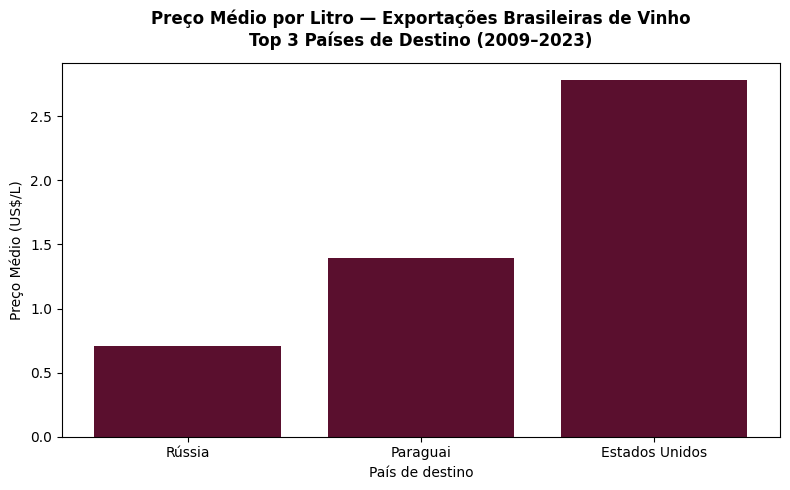

In [30]:
plt.figure(figsize=(8, 5))

plt.bar(
    top3_paises["País de destino"],
    top3_paises["Preço Médio (US$/L)"],
    color=["#5A0F2E", "#5A0F2E", "#5A0F2E"]
)

plt.title(
    "Preço Médio por Litro — Exportações Brasileiras de Vinho\nTop 3 Países de Destino (2009–2023)",
    fontweight="bold",
    pad=12
)

plt.ylabel("Preço Médio (US$/L)")
plt.xlabel("País de destino")

plt.tight_layout()
plt.show()

In [31]:
top10_paises_exportacoes_vinho = (
    exportacoes_vinho
        .groupby("País de destino", as_index=False)
        .agg({
            "Volume (L)": "sum",
            "Valor (US$)": "sum"
        })
        .sort_values("Volume (L)", ascending=False)
        .head(10)
        .reset_index(drop=True)
)

# Converter para toneladas
top10_paises_exportacoes_vinho["Volume (toneladas)"] = (
    top10_paises_exportacoes_vinho["Volume (L)"] / 1_000
)

# 🔹 Calcular preço médio corretamente
top10_paises_exportacoes_vinho["Preço Médio (US$/L)"] = (
    top10_paises_exportacoes_vinho["Valor (US$)"] /
    top10_paises_exportacoes_vinho["Volume (L)"]
)

top10_paises_exportacoes_vinho



,País de destino,Volume (L),Valor (US$),Volume (toneladas),Preço Médio (US$/L)
0,Rússia,"32,822,141.00","23,151,716.00","32,822.14",0.71
1,Paraguai,"30,803,247.00","42,862,206.00","30,803.25",1.39
2,Estados Unidos,"3,349,299.00","9,309,051.00","3,349.30",2.78
3,China,"2,574,686.00","4,903,695.00","2,574.69",1.90
4,Haiti,"2,351,228.00","3,198,849.00","2,351.23",1.36
5,Espanha,"1,990,238.00","3,805,889.00","1,990.24",1.91
6,Reino Unido,"1,150,780.00","4,640,935.00","1,150.78",4.03
7,Uruguai,"1,118,688.00","1,674,149.00","1,118.69",1.50
8,Japão,"972,341.00","2,257,163.00",972.34,2.32
9,Países Baixos,"897,986.00","3,012,934.00",897.99,3.36


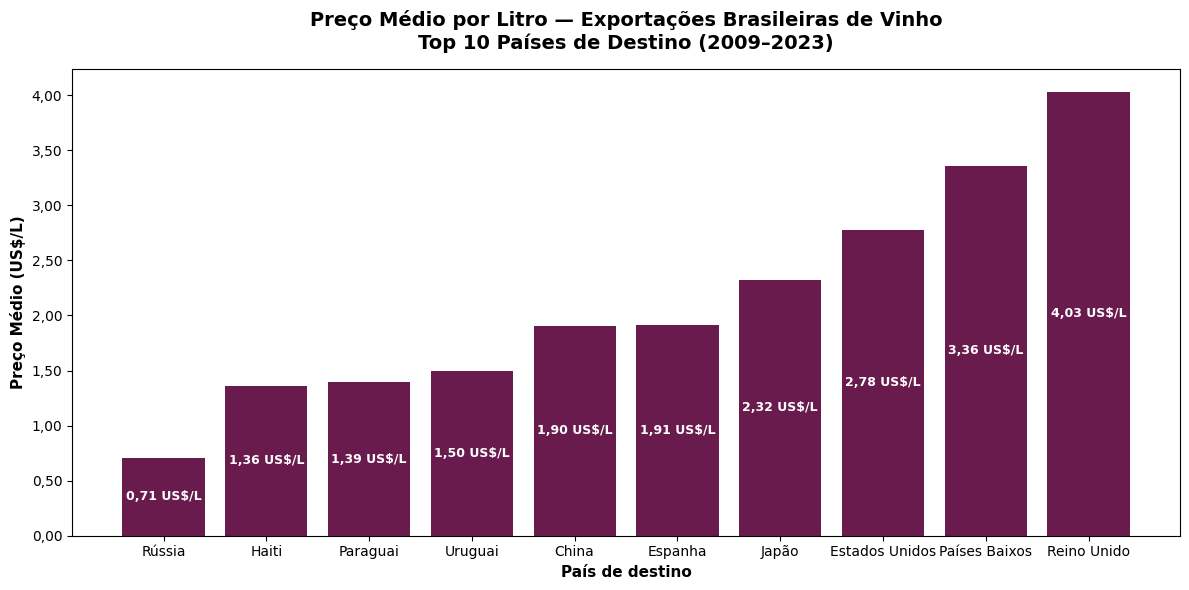

In [33]:
# Ordenar por preço médio (crescente)
top10_ord = top10_paises_exportacoes_vinho.sort_values(
    "Preço Médio (US$/L)",
    ascending=True
)

plt.figure(figsize=(12, 6))

# =========================
# Dados
paises = top10_ord["País de destino"]
precos = top10_ord["Preço Médio (US$/L)"]

# =========================
# Gráfico de barras verticais
plt.bar(
    paises,
    precos,
    color="#6A1B4D"
)

ax = plt.gca()

# =========================
# Rótulos dos eixos
ax.set_xlabel("País de destino", fontsize=11, fontweight="bold")
ax.set_ylabel("Preço Médio (US$/L)", fontsize=11, fontweight="bold")

# Formatação PT-BR (2 casas decimais)
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(
        lambda x, _: f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    )
)

# =========================
# Título
ax.set_title(
    "Preço Médio por Litro — Exportações Brasileiras de Vinho\n"
    "Top 10 Países de Destino (2009–2023)",
    fontsize=14,
    fontweight="bold",
    pad=15
)

# =========================
# Rótulos NO MEIO da barra
for i, v in enumerate(precos):
    ax.text(
        i,
        v / 2,
        f"{v:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".") + " US$/L",
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="white"
    )

plt.tight_layout()
plt.show()

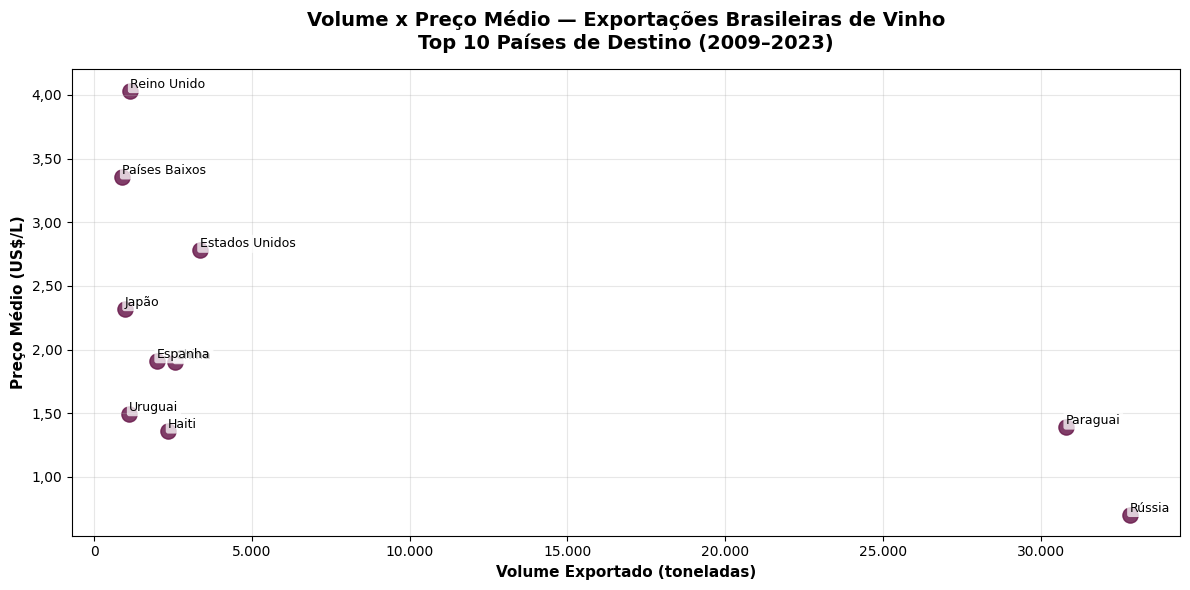

In [32]:
plt.figure(figsize=(12, 6))

# =========================
# Dados
x = top10_paises_exportacoes_vinho["Volume (toneladas)"]
y = top10_paises_exportacoes_vinho["Preço Médio (US$/L)"]
paises = top10_paises_exportacoes_vinho["País de destino"]

# =========================
# Scatter plot
plt.scatter(
    x,
    y,
    color="#6A1B4D",
    s=120,           # tamanho do ponto
    alpha=0.85
)

ax = plt.gca()

# =========================
# Rótulos dos eixos
ax.set_xlabel("Volume Exportado (toneladas)", fontsize=11, fontweight="bold")
ax.set_ylabel("Preço Médio (US$/L)", fontsize=11, fontweight="bold")

# Formatação PT-BR
ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", "."))
)
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(
        lambda v, _: f"{v:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    )
)

# =========================
# Título
ax.set_title(
    "Volume x Preço Médio — Exportações Brasileiras de Vinho\n"
    "Top 10 Países de Destino (2009–2023)",
    fontsize=14,
    fontweight="bold",
    pad=15
)

# =========================
# Rótulos dos pontos (nomes dos países)
for i, pais in enumerate(paises):
    ax.text(
        x.iloc[i],
        y.iloc[i],
        pais,
        fontsize=9,
        ha="left",
        va="bottom",
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            edgecolor="none",
            alpha=0.75
        )
    )

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

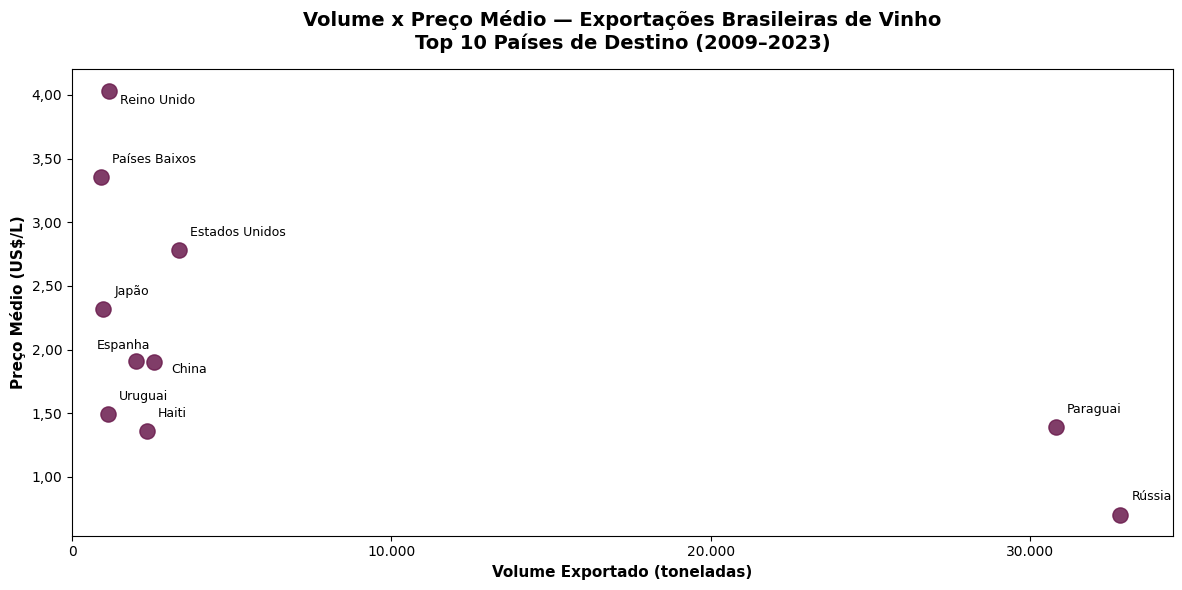

In [34]:
plt.figure(figsize=(12, 6))

# =========================
# Dados
x = top10_paises_exportacoes_vinho["Volume (toneladas)"]
y = top10_paises_exportacoes_vinho["Preço Médio (US$/L)"]
paises = top10_paises_exportacoes_vinho["País de destino"]

# =========================
# Scatter
plt.scatter(
    x,
    y,
    color="#6A1B4D",
    s=120,
    alpha=0.85
)

ax = plt.gca()

# =========================
# Eixos
ax.set_xlabel("Volume Exportado (toneladas)", fontsize=11, fontweight="bold")
ax.set_ylabel("Preço Médio (US$/L)", fontsize=11, fontweight="bold")

ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", "."))
)
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(
        lambda v, _: f"{v:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    )
)


max_x = x.max()
ticks = np.arange(0, max_x + 10_000, 10_000)

# remove o último tick (40.000)
ticks = ticks[ticks <= 30_000]

ax.set_xticks(ticks)
ax.set_xlim(0, max_x * 1.05)

ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", "."))
)

# =========================
# Título
ax.set_title(
    "Volume x Preço Médio — Exportações Brasileiras de Vinho\n"
    "Top 10 Países de Destino (2009–2023)",
    fontsize=14,
    fontweight="bold",
    pad=15
)

# =========================
# Rótulos dos países (sem caixa, com offsets pontuais)
for i, pais in enumerate(paises):
    xi, yi = x.iloc[i], y.iloc[i]

    # Offset padrão
    dx, dy = 8, 8

    # Ajustes específicos
    if pais == "China":
        dx, dy = 12, -10
    elif pais == "Espanha":
        dx, dy = -28, 6
    elif pais == "Reino Unido":
        dx, dy = 8, -12   # 🔹 desce o rótulo para não “comer” a borda

    ax.annotate(
        pais,
        (xi, yi),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=9,
        ha="left",
        va="bottom"
    )

plt.tight_layout()
plt.show()

A análise do preço médio por litro evidencia diferenças relevantes no posicionamento do vinho brasileiro entre os principais mercados de destino.

A Rússia, apesar de concentrar grandes volumes exportados, apresenta o menor preço médio por litro, indicando uma estratégia baseada em volume e competitividade de preço.

O Paraguai ocupa uma posição intermediária, com preço médio superior ao da Rússia, sugerindo maior equilíbrio entre volume e valor.

Já os Estados Unidos, mesmo com menor volume importado, apresentam o maior preço médio por litro, indicando maior valor agregado, atuação em nichos específicos e potencial para estratégias premium.

---

O Brasil exporta **muito vinho barato** para alguns mercados<br>
E **pouco vinho caro** para mercados com maior poder aquisitivo<br>

Em termos estratégicos:
- Rússia → volume alto, margem baixa
- Paraguai → estabilidade regional
- EUA → oportunidade de crescimento em valor

Isso conecta diretamente com:
- Dados demográficos (renda per capita)
- Avaliação de vinhos
- Estratégia de marca e posicionamento internacional

###**7.5. Volume × Preço Médio**<br>
- Onde o Brasil **vende muito e barato**
- Onde vende **pouco e caro**
- Onde existem **oportunidades estratégicas**

In [35]:
exportacoes_vinho = fato_comercio[
    (fato_comercio["Tipo"] == "Exportação") &
    (fato_comercio["Categoria"] == "Vinhos de mesa")
].copy()

# Agregar por país
scatter_base = (
    exportacoes_vinho
    .groupby("País de destino", as_index=False)
    .agg({
        "Volume (L)": "sum",
        "Valor (US$)": "sum"
    })
)

# Converter volume para milhões de litros
scatter_base["Volume (MM L)"] = scatter_base["Volume (L)"] / 1_000_000

# Calcular preço médio por litro
scatter_base["Preço Médio (US$/L)"] = (
    scatter_base["Valor (US$)"] / scatter_base["Volume (L)"]
)

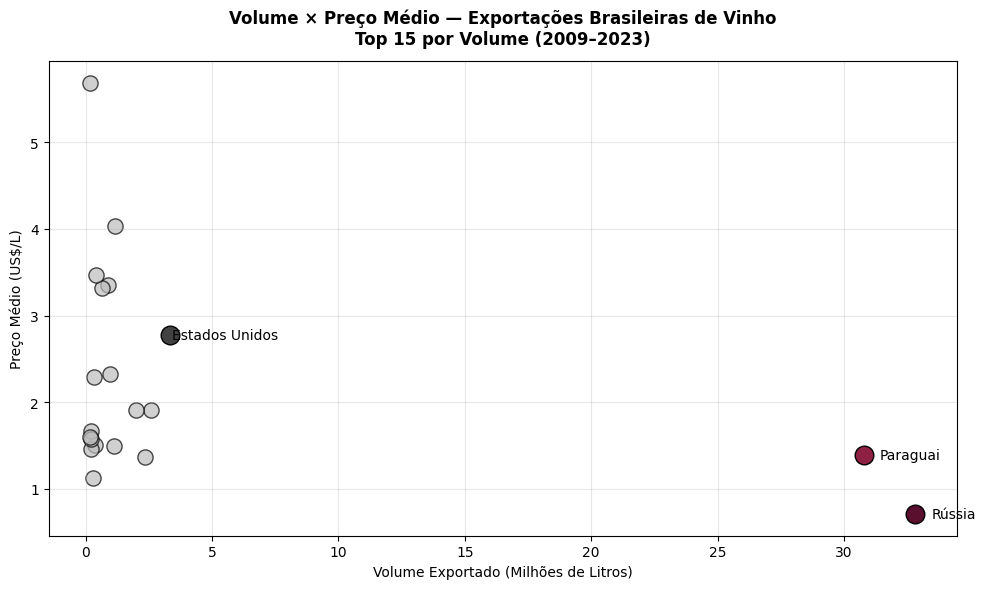

In [36]:
# 1) escolher Top N por volume (ex: 15)
topN = (
    scatter_base
    .sort_values("Volume (L)", ascending=False)
    .head(20)
    .copy()
)

# 2) países que você quer destacar (top 3)
destaque = ["Rússia", "Paraguai", "Estados Unidos"]

plt.figure(figsize=(10, 6))

# pontos do Top N (cinza)
plt.scatter(
    topN["Volume (MM L)"],
    topN["Preço Médio (US$/L)"],
    s=120,
    alpha=0.7,
    edgecolor="black",
    color="#BDBDBD"
)

# pontos destacados (coloridos + rótulo)
for pais in destaque:
    row = topN[topN["País de destino"] == pais]
    if row.empty:
        row = scatter_base[scatter_base["País de destino"] == pais]
    if not row.empty:
        x = row["Volume (MM L)"].values[0]
        y = row["Preço Médio (US$/L)"].values[0]

        plt.scatter(
            x, y,
            s=180,
            color=cores_paises.get(pais, "#424242"),
            edgecolor="black"
        )

        plt.text(x * 1.02, y, pais, fontsize=10, va="center")

plt.title("Volume × Preço Médio — Exportações Brasileiras de Vinho\nTop 15 por Volume (2009–2023)",
          fontweight="bold", pad=12)
plt.xlabel("Volume Exportado (Milhões de Litros)")
plt.ylabel("Preço Médio (US$/L)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

O gráfico de dispersão evidencia diferentes estratégias de posicionamento do vinho brasileiro nos mercados internacionais.

A Rússia se destaca como o principal destino em volume, porém com o menor preço médio por litro entre os países analisados, caracterizando uma estratégia orientada a escala e competitividade de preço.

O Paraguai apresenta elevado volume aliado a um preço médio intermediário, indicando maior equilíbrio entre volume e valor, além de estabilidade regional.

Em contraste, os Estados Unidos operam com volumes significativamente menores, porém com preço médio superior, sinalizando maior valor agregado, atuação em nichos específicos e potencial de crescimento em margem.

Esses resultados sugerem oportunidades estratégicas para diversificação das exportações brasileiras, com foco no aumento de valor agregado em mercados de maior poder aquisitivo, sem comprometer a base de volume já consolidada.

###**7.6. Conclusão**<br>
A análise das exportações brasileiras de vinho ao longo dos últimos 15 anos evidencia um cenário de crescimento concentrado em poucos mercados, com estratégias comerciais distintas entre volume e valor.

Os resultados mostram que o Brasil possui uma base sólida de exportação em termos de volume, especialmente em mercados como Rússia e Paraguai, que concentram grande parte das vendas. No entanto, esses mercados apresentam preços médios por litro mais baixos, indicando uma estratégia predominantemente orientada à escala e à competitividade de preço.

Por outro lado, mercados como os Estados Unidos, embora representem volumes menores, apresentam preço médio significativamente superior, sugerindo maior valor agregado, posicionamento em nichos específicos e maior exigência de qualidade e marca. Esse comportamento revela uma oportunidade estratégica clara para o crescimento das exportações brasileiras não apenas em volume, mas principalmente em valor e margem